In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math, ast
import plotly.express as px
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../../Dataset/target.csv')
#df = pd.concat([df, pd.read_csv('../../Dataset/glauco.csv')], axis=0)
#df = pd.concat([df, pd.read_csv('../../Dataset/pasta.csv')], axis=0)

df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   data     928 non-null    object
 1   alcohol  928 non-null    object
dtypes: object(2)
memory usage: 14.6+ KB


,data,alcohol
0,"[23534, 24013, 26216, 26172, 26108, 25037, 240...",False
1,"[23797, 24164, 26134, 26143, 26142, 26120, 253...",False
2,"[23899, 24905, 26249, 26359, 26335, 26225, 254...",False
3,"[23967, 24384, 26285, 26237, 26228, 26188, 261...",False
4,"[23859, 24287, 26269, 26188, 26115, 25477, 245...",False
...,...,...
923,"[14694,15644,18906,17094,15777,15225,15005,148...",False
924,"[18178,19026,21555,21518,20339,19240,18675,183...",False
925,"[18471,19402,22215,20945,19691,18967,18569,183...",False
926,"[19707,20551,22331,22167,21128,20471,20065,198...",False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   data     928 non-null    object
 1   alcohol  928 non-null    object
dtypes: object(2)
memory usage: 14.6+ KB


# VISUALIZAÇÃO DOS DADOS

In [4]:
df.describe()

,data,alcohol
count,928,928
unique,920,6
top,"[14736,16107,20573,20583,20539,20323,20389,203...",True
freq,2,300


In [5]:
df['alcohol'] = df.alcohol.apply(ast.literal_eval)
df['data']    = df.data.apply(ast.literal_eval)
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 928 entries, 0 to 927
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   data     928 non-null    object
 1   alcohol  928 non-null    bool  
dtypes: bool(1), object(1)
memory usage: 8.3+ KB


,data,alcohol
0,"[23534, 24013, 26216, 26172, 26108, 25037, 240...",False
1,"[23797, 24164, 26134, 26143, 26142, 26120, 253...",False
2,"[23899, 24905, 26249, 26359, 26335, 26225, 254...",False
3,"[23967, 24384, 26285, 26237, 26228, 26188, 261...",False
4,"[23859, 24287, 26269, 26188, 26115, 25477, 245...",False
...,...,...
923,"[14694, 15644, 18906, 17094, 15777, 15225, 150...",False
924,"[18178, 19026, 21555, 21518, 20339, 19240, 186...",False
925,"[18471, 19402, 22215, 20945, 19691, 18967, 185...",False
926,"[19707, 20551, 22331, 22167, 21128, 20471, 200...",False


### VALORES ÚNICOS

In [6]:
def showUnique(df):
    w = max(len(c) for c in df.columns)  # largura do maior nome de coluna

    for col in df.columns:
        try:
            unique = df[col].unique().tolist()
            N      = len(unique)
            exemplo = ', '.join(map(str, unique[:10]))
            print(f'{col:<{w}}  [{exemplo}{f" ... +{len(unique)}" if N > 10 else ""}]')
        except Exception as error:
            print(error)    

showUnique(df)

unhashable type: 'list'
alcohol  [False, True]


- Variável Alvo, verificação de desbalanceamento

In [7]:
TARGET = 'alcohol'

for label in df[TARGET].unique():
    total = (df[TARGET] == label).sum()
    print(f'classe {label}: {(total)} ({total/len(df)*100:.2f}%)')

classe False: 476 (51.29%)
classe True: 452 (48.71%)


### COLUNAS INVÁLIDAS

In [8]:
nan_rows = df[df.isna().any(axis=1)]
print(len(nan_rows), 'colunas NaN')
nan_rows

0 colunas NaN


,data,alcohol


### LINHAS INVÁLIDAS

In [9]:
nan_columns = df.columns[df.isna().any()].tolist()

for column in nan_columns:
    N = df[column].isna().sum()
    print(f'"{column}": {N} NaN rows ({N/len(df)*100:.2f}%)')

# VERIFICAÇÃO DE INTEGRIDADE

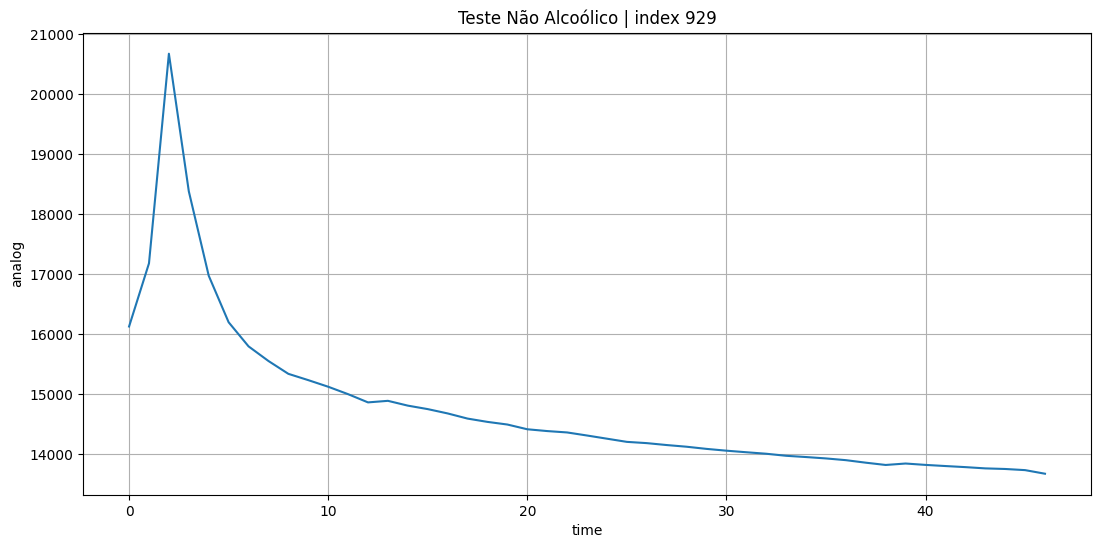

In [10]:
def plotAlcohol(data, alcohol):
    plt.plot(data)
    plt.title(f'Teste {"Alcoólico" if alcohol else "Não Alcoólico"}' + f' | index {(len(df) + 1) if index < 0 else index}')
    plt.grid(), plt.xlabel('time'), plt.ylabel('analog');


plt.figure(figsize=(13, 6))
index = -1
plotAlcohol(df.iloc[index].data, df.iloc[index].alcohol)

In [11]:
sum([len(data) == 47 for data in df.data]) == len(df)

True

# VISUALIZAÇÃO MÚLTIPLA

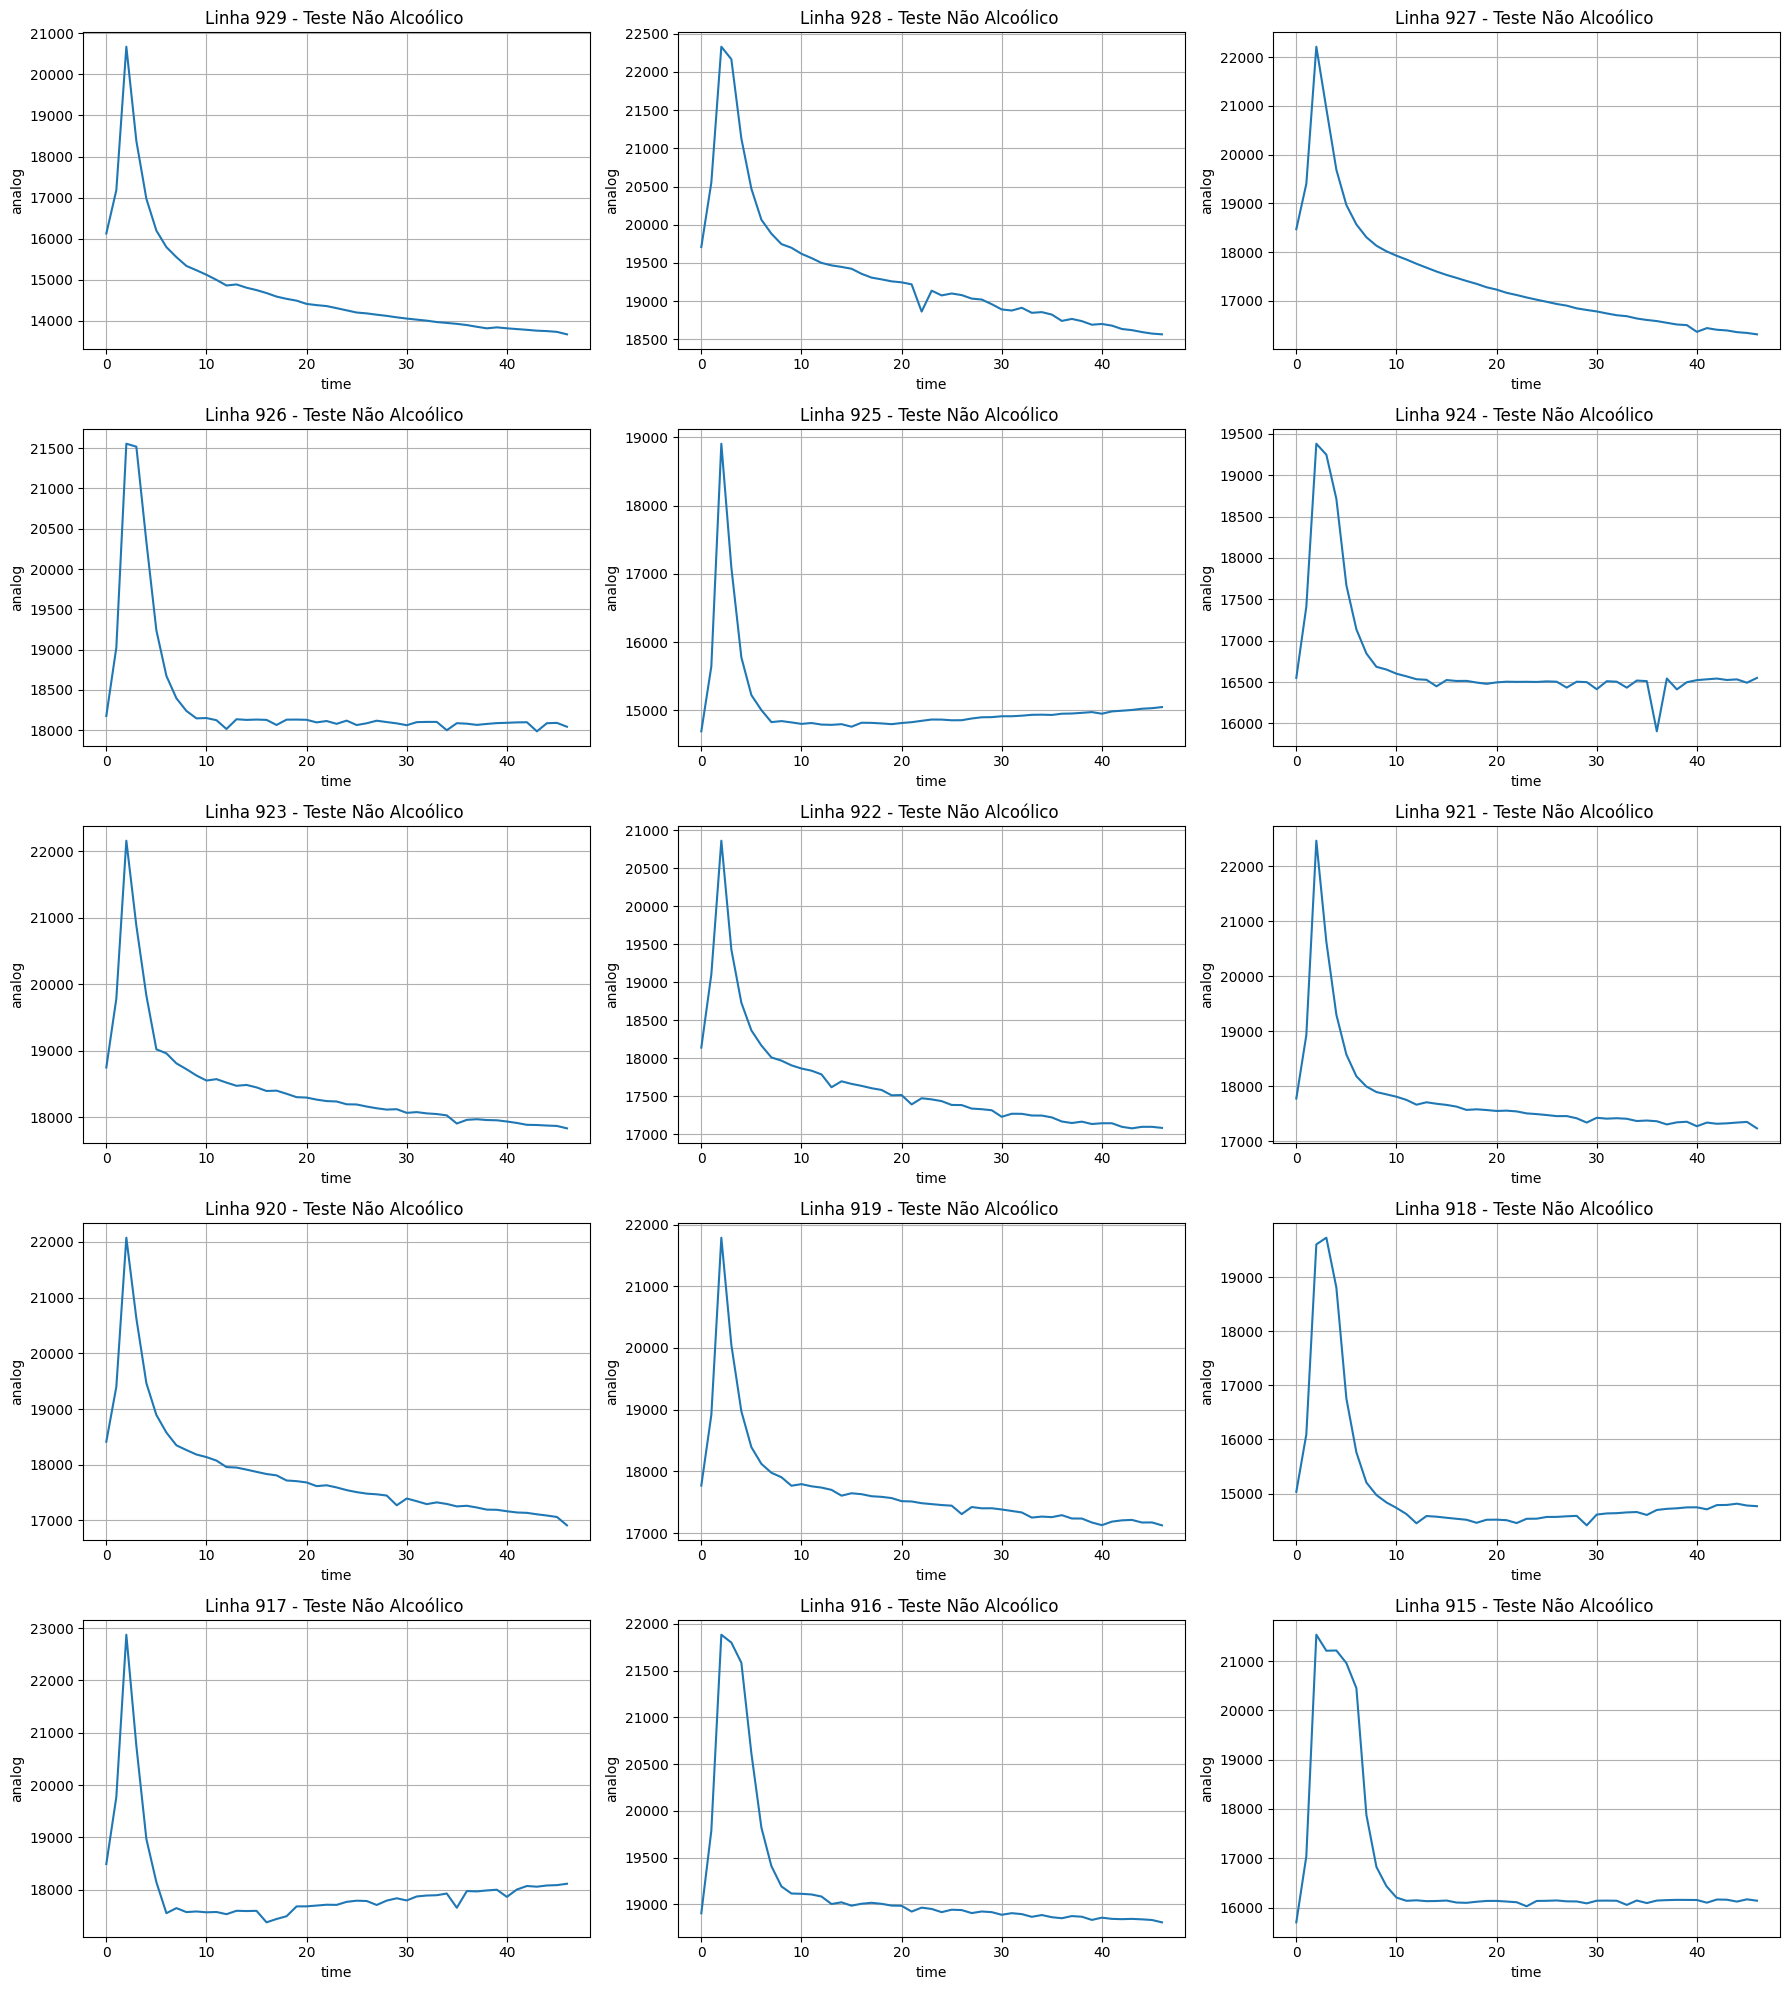

In [12]:
import math

def plotTables(df, limit=None):
    count   = len(df) if limit is None else min(limit, len(df))
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))
    
    for idx, (i, row) in enumerate(df.iterrows()):
        if idx >= count:
            break
        
        plt.subplot(numRows, numCols, idx+1)
        plt.plot(row.data)
        title  = f'Linha {i+2} - Teste {"Alcoólico" if row["alcohol"] else "Não Alcoólico"}'
        status = f''
        
        plt.title(f'{title} {status}')
        plt.grid(), plt.xlabel('time'), plt.ylabel('analog')
    
    plt.tight_layout()
    plt.show()


plotTables(df.iloc[::-1], limit=15)

# ENGENHARIA DE ATRIBUTOS

In [13]:
from scipy.stats import skew, kurtosis

In [14]:
df['mean']   = [np.mean(data) for data in df.data]
df['std']    = [np.std(data, ddof=1) for data in df.data]
df['min']    = [np.min(data) for data in df.data]
df['max']    = [np.max(data) for data in df.data]
df['first']  = [data[0] for data in df.data]
df['last']   = [data[-1] for data in df.data]
df['median'] = [np.median(data) for data in df.data]

df['amplitude'] = [np.max(data) - np.min(data) for data in df.data]
df['rise']      = [data[0]  - np.max(data) for data in df.data]
df['decay']     = [data[0] - np.min(data) for data in df.data]


#df['reldecay']  = [(np.max(data) - np.min(data))/np.mean(data) for data in df.data]
#df['residual']  = [data[-1] - data[0] for data in df.data]

df['mean_diff']   = [np.mean(np.gradient(data)) for data in df.data]
df['std_diff']    = [np.std(np.gradient(data), ddof=1) for data in df.data]
df['min_diff']    = [np.min(np.gradient(data)) for data in df.data]
df['max_diff']    = [np.max(np.gradient(data)) for data in df.data]
df['first_diff']  = [np.gradient(data)[0] for data in df.data]
df['last_diff']   = [np.gradient(data)[-1] for data in df.data]
df['median_diff'] = [np.median(np.gradient(data)) for data in df.data]

#df['time_peak'] = [np.argmax(data) for data in df.data]
#df['time_low']  = [np.argmin(data) for data in df.data]
#df['skew']      = [skew(data) for data in df.data]   # Assimetria
#df['kurt']      = [kurtosis(data) for data in df.data] # Curtose
#df['slope_ratio'] = df['min_diff'] / (df['max'] - df['min'])
#df['decayed'] = [(data[0] - np.min(data) > 1500) for data in df.data]
df.head(3)

,data,alcohol,mean,std,min,max,first,last,median,amplitude,rise,decay,mean_diff,std_diff,min_diff,max_diff,first_diff,last_diff,median_diff
0,"[23534, 24013, 26216, 26172, 26108, 25037, 240...",False,23557.723404,750.506487,23250,26216,23534,23275,23281.0,2966,-2682,284,-0.382979,334.276298,-1006.5,1341.0,479.0,3.0,-2.0
1,"[23797, 24164, 26134, 26143, 26142, 26120, 253...",False,23877.446809,756.473851,23536,26143,23797,23596,23585.0,2607,-2346,261,-0.361702,297.088420,-858.5,1168.5,367.0,1.0,0.5
2,"[23899, 24905, 26249, 26359, 26335, 26225, 254...",False,24055.574468,757.619921,23695,26359,23899,23801,23765.0,2664,-2460,204,8.680851,312.737500,-862.0,1175.0,1006.0,6.0,2.0


# CORRELAÇÕES

- **Pearson:** $\Rightarrow$ Melhor quando a relação é linear e as variáveis são numéricas contínuas com distribuição razoavelmente normal, útil para dados em escala intervalar ou de razão, exemplo, altura e peso de pessoas na mesma faixa etária.

- **Spearman:** Ideal para relações monotônicas que podem ser não lineares e para dados com outliers ou escalas ordinais, funciona com rankings e Likert, exemplo, posição em um ranking de vendas versus satisfação do cliente em escala de 1 a 5.

- **Kendall:** Preferível em amostras pequenas ou com muitos empates em dados ordinais, mais robusta e interpretável como concordância de pares, exemplo, comparar duas ordens de preferência dadas por juízes.

{'decay': 0.7034845873982469,
 'mean_diff': -0.6234515819963052,
 'min': -0.579089452259664,
 'mean': -0.5442020560943983,
 'median': -0.5358765176012056,
 'last': -0.5056402422510522,
 'rise': 0.48510559823276284,
 'std': 0.48398544561008844,
 'amplitude': 0.480061092269794,
 'max_diff': -0.4370112850659577,
 'min_diff': -0.41389169591885855,
 'max': -0.36701846031724605,
 'first_diff': -0.34540446673058206,
 'median_diff': 0.17411052184745324,
 'std_diff': 0.1457006605210185,
 'first': -0.09280366352166464,
 'last_diff': 0.0798372963976827}

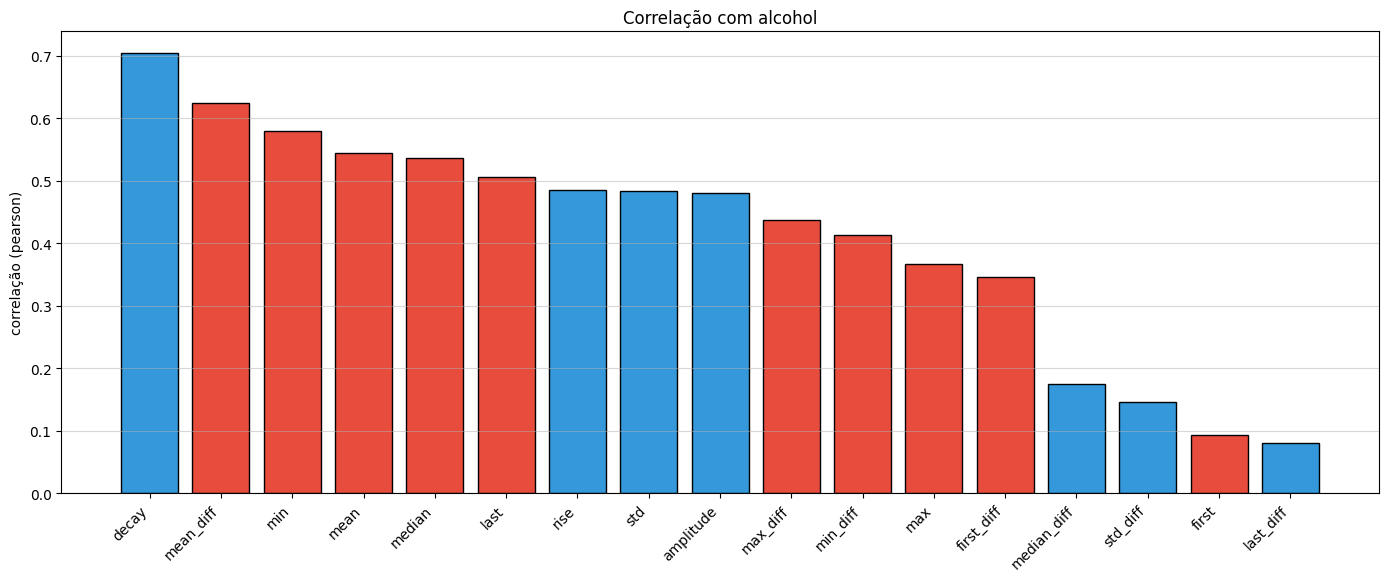

In [15]:
class Correlations:
    def __init__(self, df, tresh=0.5, method='pearson'):
        self.df = df.copy()
        self.tresh  = tresh
        self.method = method
        self.matrix = self.df.corr(method=self.method)

    def get(self, target_col):
        if target_col not in self.matrix.columns:
            return {}
            
        corr = self.matrix[target_col].drop(target_col)
        keep = corr[abs(corr) >= self.tresh].sort_values(key=abs, ascending=False)        
        return {ref: corr for ref, corr in keep.items()}
    
    def all(self):
        result = {}
        for col in self.matrix.columns:
            info = self.get(col)
            if len(info) > 0:
                result[col] = info
        return result
    
    def plot(self, target_col, show_max=None):
        corrs = self.get(target_col)
        
        if not corrs: 
            return
        
        original_values = self.matrix.loc[list(corrs.keys()), target_col]
        labels = [str(label)[:20] for label in corrs.keys()]
        values = [abs(v) for v in corrs.values()] # Altura da barra = Importância
        
        colors = ['#3498db' if original_values[label] > 0 else '#e74c3c' for label in corrs.keys()]
        plt.bar(labels[:show_max], values[:show_max], color=colors[:show_max], edgecolor='black')
        plt.title(f'Correlação com {target_col}')
        plt.ylabel(f'correlação ({self.method})'); plt.grid(axis='y', alpha=0.5)

        if len(corrs) >= 4:
            plt.xticks(rotation=45, ha='right')
    
    def heatmap(self, target_col, n=None):
        if target_col not in self.matrix.columns: 
            return

        top_cols = self.matrix[target_col].abs().sort_values(ascending=False).drop(target_col)
        
        if n: 
            top_cols = top_cols.head(n)
        
        cols_to_plot  = [target_col] + top_cols.index.tolist()
        matrix_subset = self.matrix.loc[cols_to_plot, cols_to_plot]

        plt.figure(figsize=(17, 10))
        sns.heatmap(matrix_subset.abs(), annot=True, fmt=".2f", cmap='Blues', vmin=0, vmax=1)
        plt.title(f'Mapa de Calor (Top {n})')
        plt.xticks(rotation=45, ha='right')
        plt.show()


df_corr = df.drop(columns=['data'])
corr    = Correlations(df_corr, tresh=0.00)
plt.figure(figsize=(17, 6))
corr.plot(TARGET, show_max=None)
corr.get(TARGET)

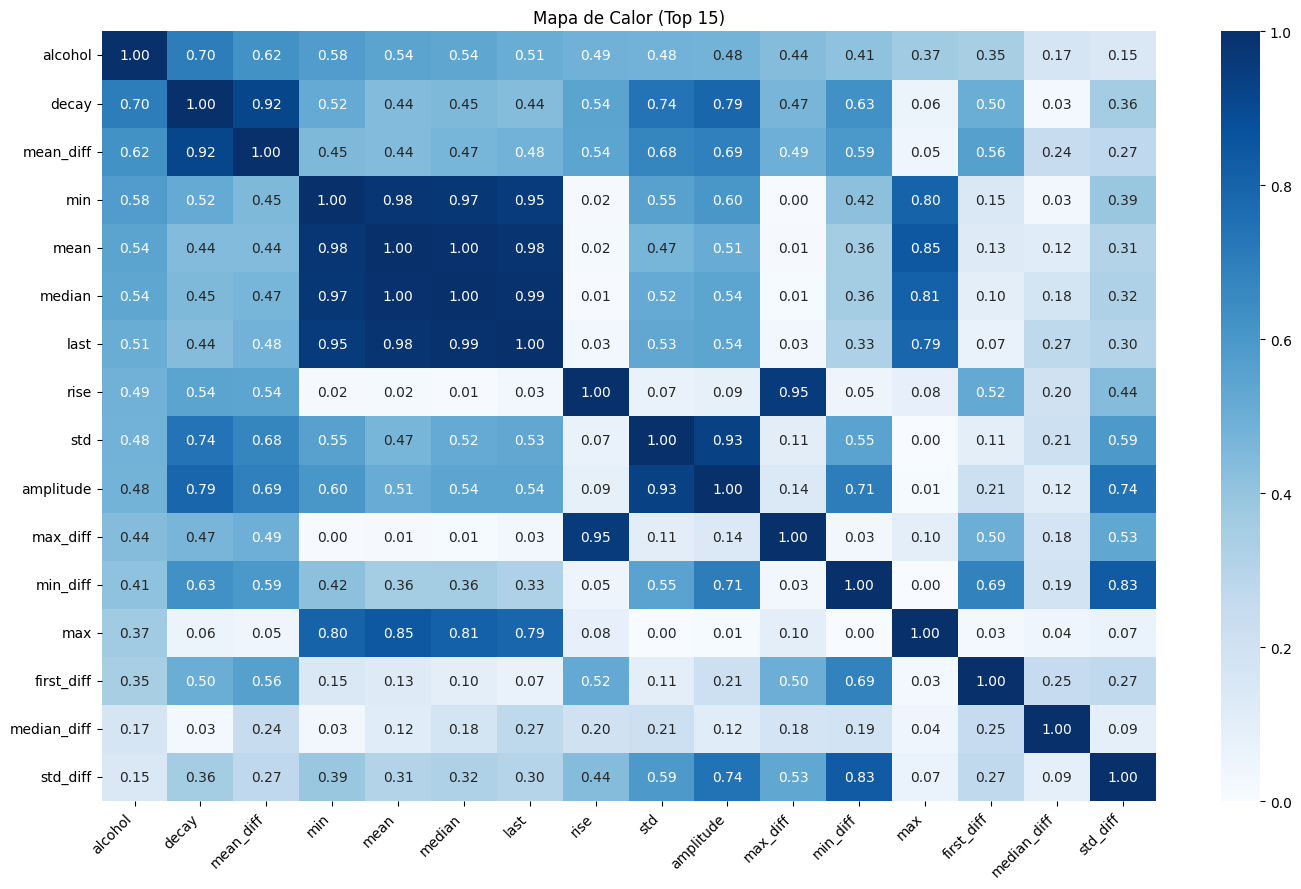

In [16]:
corr.heatmap(TARGET, n=15)

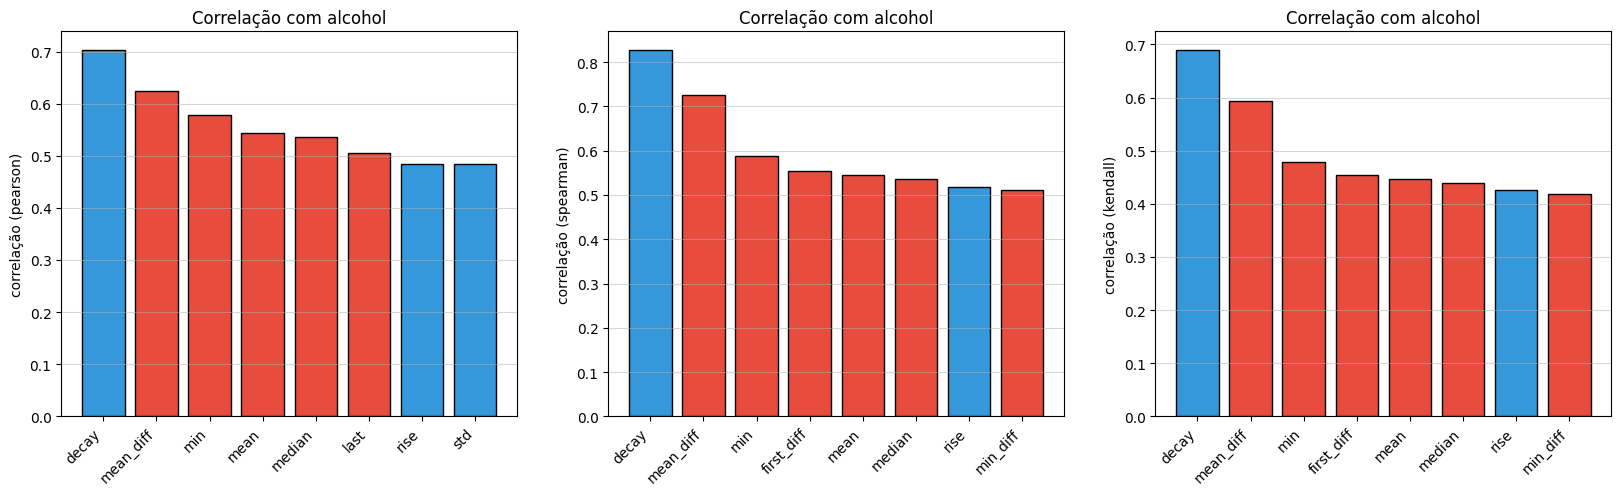

In [17]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
Correlations(df_corr, tresh=0, method='pearson').plot(TARGET, show_max=8)

plt.subplot(1, 3, 2)
Correlations(df_corr, tresh=0, method='spearman').plot(TARGET, show_max=8)

plt.subplot(1, 3, 3)
Correlations(df_corr, tresh=0, method='kendall').plot(TARGET, show_max=8)

# SELEÇÃO

In [18]:
USE_PCA = True

In [19]:
CORR_TRESH = 0.10
best_corr  = list(Correlations(df_corr, tresh=CORR_TRESH).get(TARGET))
best_corr

['decay',
 'mean_diff',
 'min',
 'mean',
 'median',
 'last',
 'rise',
 'std',
 'amplitude',
 'max_diff',
 'min_diff',
 'max',
 'first_diff',
 'median_diff',
 'std_diff']

In [20]:
df = df[best_corr + [TARGET, 'data']]
df

,decay,mean_diff,min,mean,median,last,rise,std,amplitude,max_diff,min_diff,max,first_diff,median_diff,std_diff,alcohol,data
0,284,-0.382979,23250,23557.723404,23281.0,23275,-2682,750.506487,2966,1341.0,-1006.5,26216,479.0,-2.0,334.276298,False,"[23534, 24013, 26216, 26172, 26108, 25037, 240..."
1,261,-0.361702,23536,23877.446809,23585.0,23596,-2346,756.473851,2607,1168.5,-858.5,26143,367.0,0.5,297.088420,False,"[23797, 24164, 26134, 26143, 26142, 26120, 253..."
2,204,8.680851,23695,24055.574468,23765.0,23801,-2460,757.619921,2664,1175.0,-862.0,26359,1006.0,2.0,312.737500,False,"[23899, 24905, 26249, 26359, 26335, 26225, 254..."
3,444,-4.787234,23523,24066.489362,23586.0,23553,-2318,951.326599,2762,1159.0,-796.0,26285,417.0,-3.5,286.202777,False,"[23967, 24384, 26285, 26237, 26228, 26188, 261..."
4,33,6.361702,23826,24297.723404,23938.0,23943,-2410,723.535964,2443,1205.0,-849.5,26269,428.0,2.0,397.356656,False,"[23859, 24287, 26269, 26188, 26115, 25477, 245..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
923,0,17.829787,14694,15062.361702,14902.0,15049,-4212,681.228667,4212,2106.0,-1564.5,18906,950.0,7.0,451.318254,False,"[14694, 15644, 18906, 17094, 15777, 15225, 150..."
924,191,5.659574,17987,18356.382979,18104.0,18044,-3377,782.950372,3568,1688.5,-1139.0,21555,848.0,-6.0,410.435176,False,"[18178, 19026, 21555, 21518, 20339, 19240, 186..."
925,2157,-36.297872,16314,17438.914894,17070.0,16314,-3744,1210.949319,5901,1872.0,-1262.0,22215,931.0,-44.5,418.890248,False,"[18471, 19402, 22215, 20945, 19691, 18967, 185..."
926,1143,-15.446809,18564,19344.531915,19099.0,18564,-2624,828.749447,3767,1312.0,-848.0,22331,844.0,-29.0,318.034286,False,"[19707, 20551, 22331, 22167, 21128, 20471, 200..."


# SALVANDO O MODELO

In [21]:
df.to_csv('../../Dataset/model.csv', index=None)